In [1166]:
import pandas as pd
import numpy as np
from src.paths import *
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import mannwhitneyu
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import make_scorer, precision_score, recall_score,f1_score, roc_auc_score,average_precision_score, confusion_matrix, ConfusionMatrixDisplay,  brier_score_loss

## Read the data

In [1167]:
df = pd.read_csv(CLEAN_PATH / 'merged_cleaned.csv', index_col=0)

## Map the occurrence status to values
If a red tide is present, set to 1. If a red tide is absent, set to 0.

In [1168]:
df['red_tide'] = df['occurrenceStatus'].map({'present':1,'absent':0})

## Select features to analyze
Select only environmental conditions or factors

In [1169]:
features = [
    'chlorophyll',
    'phaeopigment',
    'nitrate',
    'phosphate',
    'silicon',
    'temp',
    'salinity',
    'oxygen_sat',
    'oxygen_con',
    'avg_depth'
]

In [1170]:
labels = {
    'chlorophyll': 'Chlorophyll (µg/L)',
    'phaeopigment': 'Phaeopigment (µg/L)',
    'nitrate': 'Nitrate (µM)',
    'phosphate': 'Phosphate (µM)',
    'silicon': 'Silicon (µM)',
    'temp': 'Temperature (°C)',
    'salinity': 'Salinity (g/kg)',
    'oxygen_sat': 'Oxygen saturation (%)',
    'oxygen_con': 'Oxygen concentration (µM)',
    'avg_depth': 'Secchi depth (m)'
}

## Use box plots to observe values during the absence and presence of a red tide
This helps us visually see the difference between features when HABs are absent and present.

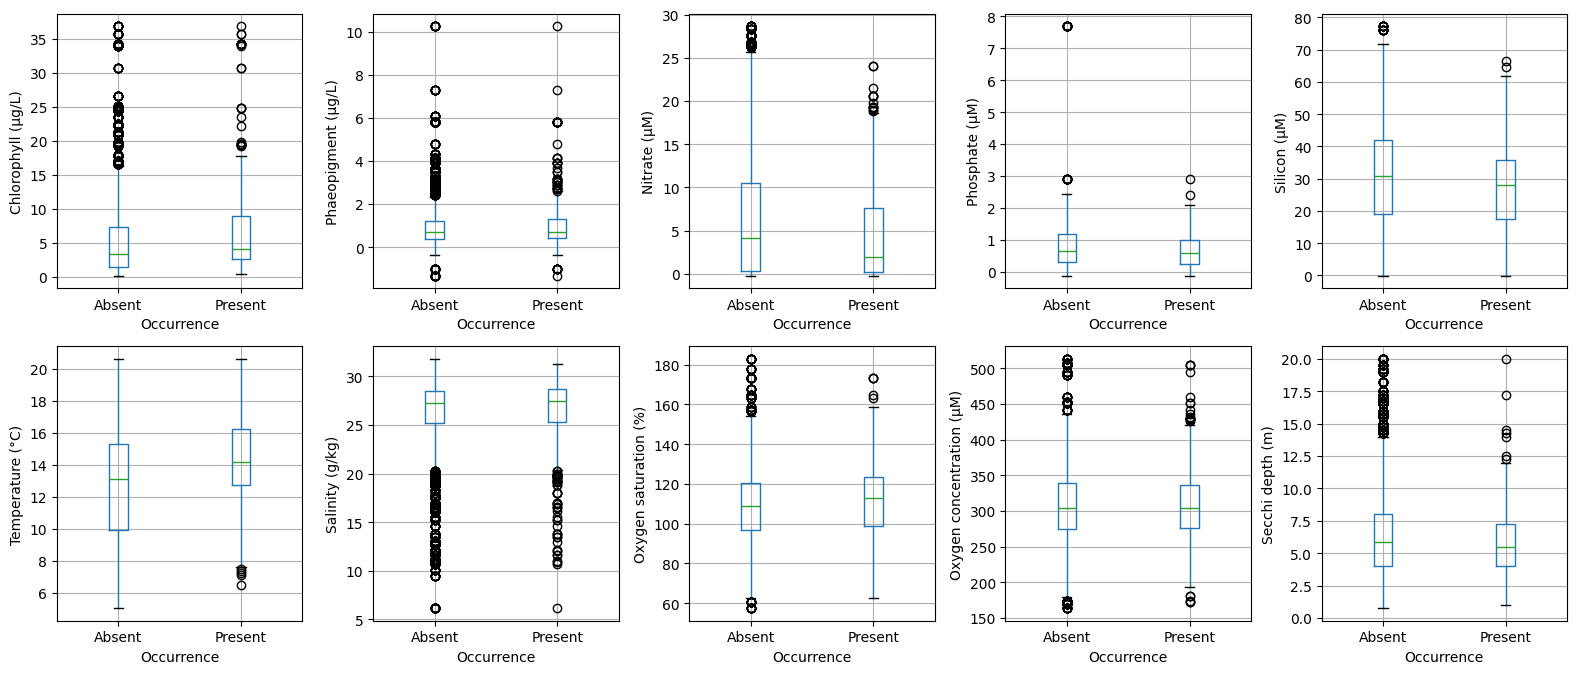

In [1171]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for feat, ax in zip(features, axes):
    df.boxplot(column=feat,by='red_tide',ax=ax)
    ax.set_title('')
    ax.set_xlabel('Occurrence')
    ax.set_ylabel(labels.get(feat, feat))
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Absent', 'Present'])

plt.suptitle('')
plt.tight_layout()
plt.show()

## Determine correlations between each feature
This helps us identify if there are any predictors that are similar, which can be later dropped to avoid [multicollinearity](https://en.wikipedia.org/wiki/Multicollinearity).

For simplicity, we will remove features whose coeff correlation is > 0.90

In [1172]:
corr = df[features].corr().round(2) # Round it to 2 decimal places for clarity

# Housekeeping...
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

print(corr)

              chlorophyll  phaeopigment  nitrate  phosphate  silicon  temp  salinity  oxygen_sat  oxygen_con  avg_depth
chlorophyll          1.00          0.39    -0.25      -0.17    -0.22 -0.13      0.09        0.37        0.42      -0.39
phaeopigment         0.39          1.00    -0.16      -0.11    -0.10 -0.01     -0.02        0.29        0.31      -0.25
nitrate             -0.25         -0.16     1.00       0.75     0.67 -0.59      0.13       -0.46       -0.23       0.24
phosphate           -0.17         -0.11     0.75       1.00     0.43 -0.47      0.21       -0.41       -0.24       0.22
silicon             -0.22         -0.10     0.67       0.43     1.00 -0.36     -0.16       -0.43       -0.26      -0.02
temp                -0.13         -0.01    -0.59      -0.47    -0.36  1.00     -0.26        0.22       -0.16      -0.13
salinity             0.09         -0.02     0.13       0.21    -0.16 -0.26      1.00       -0.13       -0.17       0.36
oxygen_sat           0.37          0.29 

## Determine correlation with red tides
Helps us determine the direction and strength of each feature and the red tides.

- **positive correlation**: higher value to occur with red tide **presence**
- **negative correlation**: higher values occur with red tide **absence**
- **correlation near zero**: weak simple relationship.

In [1173]:
rt_corr = (df[features + ['red_tide']].corr()['red_tide'].drop('red_tide'))
print(rt_corr)

chlorophyll     0.070022
phaeopigment    0.019906
nitrate        -0.086128
phosphate      -0.063410
silicon        -0.056203
temp            0.114083
salinity        0.019260
oxygen_sat      0.043029
oxygen_con     -0.007544
avg_depth      -0.052882
Name: red_tide, dtype: float64


## Plot the features to check distribution shape

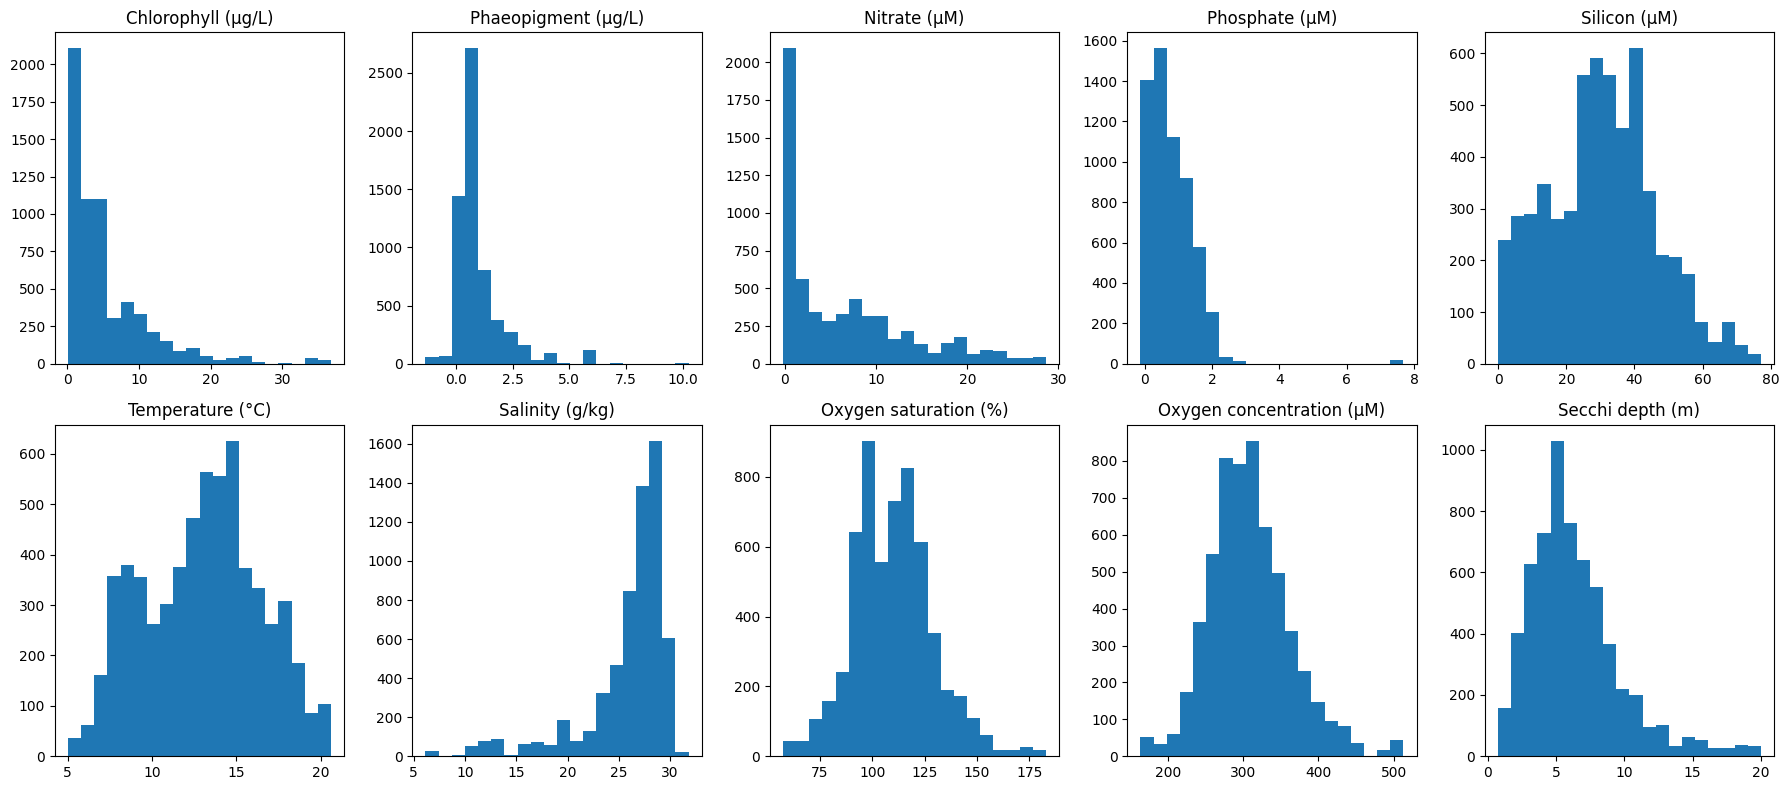

In [1174]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    ax.hist(df[feat], bins=20)
    ax.set_title(labels.get(feat, feat))

plt.tight_layout()
plt.show()

## Perform a Mann-Whitney U-Test
Choose a [mann-whitney test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html) because it doesn't need normal distributed data. Helps us determine which environmental features differ between red tide presence and absence observations.

## Calculate the median difference to see the median of the feature during the presence of red tides. 
- **Positive difference**: feature is x units higher
- **Negative difference**: feature is x unis lower

## Calculate an effect size
Effect sizes describes the magnitude and direction of the difference. Evaluate using the absolute value of the calculated magnitude to make clear analyses.

- **Positive effect**: values are larger during red tides
- **Negative effect**: values are smaller during red tides
- **Near zero**: overlaps in groups
- **Larger abs values**: Strong separation


In [1175]:
results = []

for feature in features:
    absent = df.loc[df['red_tide'] == 0, feature].dropna() 
    present = df.loc[df['red_tide'] == 1, feature].dropna() 
    
    # check in case absent or present have nothing
    if absent.empty or present.empty:
        print(f'{feature:20s} no data')
        continue    
    
    # Perform a two-tailed Mann-Whitney U-test
    stats, p = mannwhitneyu(absent, present, alternative='two-sided')    
    
    # Create a rank-biserial correlation
    effect = 1 - (2 * stats) / (len(absent) * len(present))
   
    # Interpret the effect size
    mag = abs(effect)
    if mag < 0.1:       interpret = 'Very small'
    elif (mag < 0.3):   interpret = 'Small'
    elif (mag < 0.5):   interpret = 'Moderate'
    else:               interpret = 'Large'
    

    # Create a dictionary 
    results.append({
        'Feature': feature,         
        'Absent Median': absent.median(),                           # Median of the feature when HAB is absent
        'Present Median': present.median(),                         # Median of the feature when HAB is present
        'Median Difference': present.median() - absent.median(),    # Difference
        'Effect Size': effect,
        'Effect Interpretation': interpret,
        'p-value': p,
    })
    
    
results = pd.DataFrame(results)


# Adjust p-values
# Use holm method for less strictness
r, corrected_p, _, _ = multipletests(results['p-value'], method='holm', alpha=0.05)
results['Adjusted-p'] = corrected_p
results['Reject'] = r   # True: Reject null hypothesis and say there is a difference


# Housekeeping...
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)


print(results)

        Feature  Absent Median  Present Median  Median Difference  Effect Size Effect Interpretation       p-value    Adjusted-p  Reject
0   chlorophyll       3.369787        4.101405           0.731618     0.184254                 Small  2.161119e-12  1.945007e-11    True
1  phaeopigment       0.687944        0.724580           0.036636     0.037575            Very small  1.520526e-01  3.041051e-01   False
2       nitrate       4.200000        1.900000          -2.300000    -0.155813                 Small  1.053255e-08  8.426042e-08    True
3     phosphate       0.660000        0.590000          -0.070000    -0.128817                 Small  2.916171e-06  2.041320e-05    True
4       silicon      30.770000       27.980000          -2.790000    -0.110731                 Small  4.944211e-05  2.966527e-04    True
5          temp      13.090000       14.173000           1.083000     0.231745                 Small  1.011684e-18  1.011684e-17    True
6      salinity      27.258000       27.5

### Determine model features
This is the result of removing anything that is strongly correlated with each other. For example, oxygen saturation and oxygen concentration were strongly correlated, so we continue our analysis with only oxygen saturation.

In [1176]:
model_features = [
    'chlorophyll',
    'phaeopigment',
    'nitrate',
    'phosphate',
    'silicon',
    'temp',
    'salinity',
    'oxygen_sat',
    'avg_depth'
]

## Use VIF to further determine correlations


In [1177]:
X_vif = df[model_features].dropna()

# Add a constant
X_vif = sm.add_constant(X_vif)


vif = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})


# Remove the constant
vif = vif[vif['Feature'] != 'const'] 

# Interpret the data
vif['Interpretation'] = vif['VIF'].apply(lambda x: 'PASS' if x < 5 else 'FAIL')

print(vif)

        Feature       VIF Interpretation
1   chlorophyll  1.788770           PASS
2  phaeopigment  1.253893           PASS
3       nitrate  4.950287           PASS
4     phosphate  2.405217           PASS
5       silicon  2.429942           PASS
6          temp  1.939135           PASS
7      salinity  1.406291           PASS
8    oxygen_sat  1.622157           PASS
9     avg_depth  1.636732           PASS


## Perform a multivariable logistic regression
Helps us further analyze which environmental features are associated with red tide presence after accounting for other features. 

Perform a multivariable one to separate any potential overlap between correlating features.

In [1178]:
# Select the model features and the red tide info, dropping any NaN values.
model_lr = df[model_features + ['red_tide']].dropna() 

X = model_lr[model_features]
y = model_lr['red_tide']

X_scaled = StandardScaler().fit_transform(X)

model = LogisticRegression(max_iter=5000)
model.fit(X_scaled, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [1179]:
model_results = pd.DataFrame({
    'Feature': model_features,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0]) # odds ratio = e^coeff
}) 

model_results['abs(Coefficient)'] = (model_results['Coefficient'].abs())

print(model_results)

        Feature  Coefficient  Odds Ratio  abs(Coefficient)
0   chlorophyll     0.222732    1.249486          0.222732
1  phaeopigment    -0.015152    0.984963          0.015152
2       nitrate     0.071603    1.074228          0.071603
3     phosphate    -0.066594    0.935575          0.066594
4       silicon    -0.054247    0.947199          0.054247
5          temp     0.493059    1.637318          0.493059
6      salinity     0.273922    1.315113          0.273922
7    oxygen_sat    -0.027190    0.973176          0.027190
8     avg_depth    -0.245192    0.782554          0.245192


## Create a pipeline
Impute missing data, standardize the data, then perform logistic regression.

Use median value because it is less sensitive to outliers.

Standardize feature values because they have different magnitudes

In [1180]:
model = Pipeline([
    ('scaler', StandardScaler()), # Standardize predictors
    ('logistic', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

model_unweighted = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=2000, random_state=42))
])

## Perform a cross-validation

Use stratified folds so the present red-tides stay somewhat consistent across each fold. 

In [1181]:
# Define a dictionary of scores
scoring = {
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy',
    'average_precision': 'average_precision',
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'sensitivity': make_scorer(recall_score, pos_label=1, zero_division=0),
    'specificity': make_scorer(recall_score, pos_label=0, zero_division=0),
    'f1': make_scorer(f1_score, pos_label=1, zero_division=0)
}

cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(estimator=model, X=X, y=y, cv=cross_validation, scoring=scoring)
cv_results_unweighted = cross_validate(estimator=model_unweighted, X=X, y=y, cv=cross_validation, scoring=scoring)

# print(cv_results)

## Analyze balanced data

In [1182]:
summary = pd.DataFrame({
    'Metric': [
        'ROC AUC',
        'Balanced Accuracy',
        'Average precision',
        'Precision',
        'Sensitivity',
        'Specificity',
        'F1'
    ],

    'Mean': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_balanced_accuracy'].mean(),
        cv_results['test_average_precision'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_sensitivity'].mean(),
        cv_results['test_specificity'].mean(),
        cv_results['test_f1'].mean(),
    ],

    'Standard deviation': [
        cv_results['test_roc_auc'].std(),
        cv_results['test_balanced_accuracy'].std(),
        cv_results['test_average_precision'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_sensitivity'].std(),
        cv_results['test_specificity'].std(),
        cv_results['test_f1'].std(),
    ]
})


print(summary.to_string(index=False))

           Metric     Mean  Standard deviation
          ROC AUC 0.641580            0.026544
Balanced Accuracy 0.587828            0.030290
Average precision 0.143379            0.016265
        Precision 0.113609            0.010564
      Sensitivity 0.605613            0.053154
      Specificity 0.570042            0.011739
               F1 0.191318            0.017581


## Analyze unweighted data

In [1183]:
summary_unweighted = pd.DataFrame({
    'Metric': [
        'ROC AUC',
        'Balanced Accuracy',
        'Average precision',
        'Precision',
        'Sensitivity',
        'Specificity',
        'F1'
    ],

    'Mean': [
        cv_results_unweighted['test_roc_auc'].mean(),
        cv_results_unweighted['test_balanced_accuracy'].mean(),
        cv_results_unweighted['test_average_precision'].mean(),
        cv_results_unweighted['test_precision'].mean(),
        cv_results_unweighted['test_sensitivity'].mean(),
        cv_results_unweighted['test_specificity'].mean(),
        cv_results_unweighted['test_f1'].mean(),
    ],

    'Standard deviation': [
        cv_results_unweighted['test_roc_auc'].std(),
        cv_results_unweighted['test_balanced_accuracy'].std(),
        cv_results_unweighted['test_average_precision'].std(),
        cv_results_unweighted['test_precision'].std(),
        cv_results_unweighted['test_sensitivity'].std(),
        cv_results_unweighted['test_specificity'].std(),
        cv_results_unweighted['test_f1'].std(),
    ]
})

print(summary_unweighted.to_string(index=False))

           Metric     Mean  Standard deviation
          ROC AUC 0.640521            0.028919
Balanced Accuracy 0.500000            0.000000
Average precision 0.144148            0.019960
        Precision 0.000000            0.000000
      Sensitivity 0.000000            0.000000
      Specificity 1.000000            0.000000
               F1 0.000000            0.000000


## Perform an out-of-fold cross_validation
Create a set of more realistic predictions instead of the cross-validation trained on the same observations 

In [1184]:
out_of_fold_prob = cross_val_predict(model, X, y, cv=cross_validation, method='predict_proba')[:, 1]
out_of_fold_pred = (out_of_fold_prob >= 0.5).astype(int)

## Construct a confusion matrix

In [1185]:
confusion_m = confusion_matrix(y, out_of_fold_pred, labels=[0, 1])

true_neg, false_pos, false_neg, true_pos = confusion_m.ravel()

print('Values for balanced')
print('True negatives: ', true_neg, '(absence of a red tide, predicted absent, got it right.)')
print('False positives:', false_pos, '(absence of a red tide, predicted present, got it wrong.)')
print('False negatives:', false_neg, '(presence of a red tide, predicted absent, got it wrong.)')
print('True positives: ', true_pos, '(presence of a red tide, predicted present, got it right.)')

precision = (true_pos / (true_pos + false_pos)) * 100
sensitivity = (true_pos / (true_pos + false_neg)) * 100
specificity = (true_neg / (true_neg + false_pos)) * 100

print(f'Precision:   {precision:.1f}%')
print(f'Sensitivity (detection of actual red tide observations): {sensitivity:.1f}%')
print(f'Specificity (rejection of red tide absences): {specificity:.1f}%')

# todo: what about the other metrics?

Values for balanced
True negatives:  2702 (absence of a red tide, predicted absent, got it right.)
False positives: 2038 (absence of a red tide, predicted present, got it wrong.)
False negatives: 170 (presence of a red tide, predicted absent, got it wrong.)
True positives:  261 (presence of a red tide, predicted present, got it right.)
Precision:   11.4%
Sensitivity (detection of actual red tide observations): 60.6%
Specificity (rejection of red tide absences): 57.0%


In [1186]:
out_of_fold_prob_unweighted = cross_val_predict(model_unweighted, X, y, cv=cross_validation, method='predict_proba', n_jobs=1)[:, 1]
out_of_fold_pred_unweighted = (out_of_fold_prob_unweighted >= 0.5).astype(int)

In [1187]:
confusion_m_unweighted = confusion_matrix(y, out_of_fold_pred_unweighted, labels=[0, 1])
true_neg_uw, false_pos_uw, false_neg_uw, true_pos_uw = confusion_m_unweighted.ravel()

# Unweighted
print('Values for unweighted')
print('True negatives for unweighted: ', true_neg_uw, '(absence of a red tide, predicted absent, got it right.)')
print('False positives for unweighted:', false_pos_uw, '(absence of a red tide, predicted present, got it wrong.)')
print('False negatives for unweighted:', false_neg_uw, '(presence of a red tide, predicted absent, got it wrong.)')
print('True positives for unweighted: ', true_pos_uw, '(presence of a red tide, predicted present, got it right.)')

precision_uw = (true_pos_uw / (true_pos_uw + false_pos_uw)) * 100 if (true_pos_uw + false_pos_uw) > 0 else np.nan
sensitivity_uw = (true_pos_uw / (true_pos_uw + false_neg_uw)) * 100 
specificity_uw = (true_neg_uw / (true_neg_uw + false_pos_uw)) * 100

print(f'Precision for unweighted:   {precision_uw:.1f}%') # Undefined
print(f'Sensitivity for unweighted (detection of actual red tide observations): {sensitivity_uw:.1f}%')
print(f'Specificity for unweighted (rejection of red tide absences): {specificity_uw:.1f}%')

Values for unweighted
True negatives for unweighted:  4740 (absence of a red tide, predicted absent, got it right.)
False positives for unweighted: 0 (absence of a red tide, predicted present, got it wrong.)
False negatives for unweighted: 431 (presence of a red tide, predicted absent, got it wrong.)
True positives for unweighted:  0 (presence of a red tide, predicted present, got it right.)
Precision for unweighted:   nan%
Sensitivity for unweighted (detection of actual red tide observations): 0.0%
Specificity for unweighted (rejection of red tide absences): 100.0%


### ROC AUC Score
[ROC AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) computes the area under the receiver operating characteristic curve from prediction scores.

See if the model was able to classify the observations correctly.
- 0.5: meh
- 1: good job.

This uses the out of fold instead of the regular cross_validation value

In [1188]:
roc_auc = roc_auc_score(y, out_of_fold_prob)
print(f'ROC AUC score: {roc_auc:.3f}')

roc_auc_unweighted = roc_auc_score(y, out_of_fold_prob_unweighted)
print(f'ROC AUC unweighted score: {roc_auc_unweighted:.3f}')

ROC AUC score: 0.640
ROC AUC unweighted score: 0.639


### Brier Score Loss
[Brier Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html) measures the MSD between predicted probabilty and actual outcome. The smaller value, the better.

In [1189]:
brier = brier_score_loss(y, out_of_fold_prob)
brier_unweighted = brier_score_loss(y, out_of_fold_prob_unweighted)

prevalence = y.mean()
baseline_probability = np.full(len(y), prevalence)
baseline_brier = brier_score_loss(y, baseline_probability)

print(f'HAB prevalence:         {prevalence:.3f}')
print(f'Brier score:            {brier:.3f}')
print(f'Brier unweighted score: {brier_unweighted:.3f}')
print(f'Baseline Brier score:   {baseline_brier:.3f}')

HAB prevalence:         0.083
Brier score:            0.233
Brier unweighted score: 0.075
Baseline Brier score:   0.076


## Plot the calibration curve

### Balanced

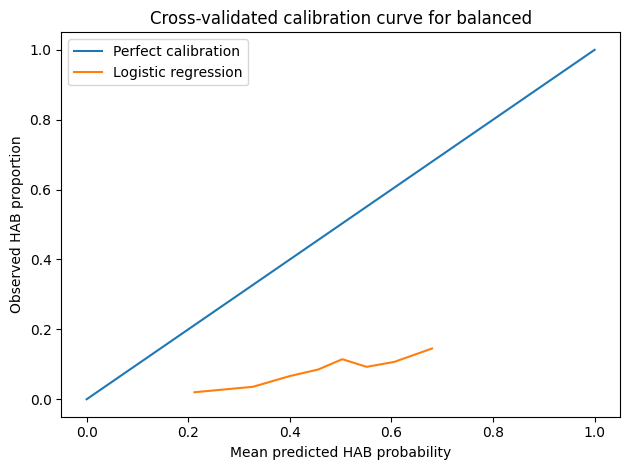

In [1190]:
obs_p, p_p = calibration_curve(y_true=y, y_prob=out_of_fold_prob, n_bins=8, strategy='quantile')

plt.figure()

plt.plot([0, 1], [0, 1], label='Perfect calibration')

plt.plot(p_p, obs_p, label='Logistic regression')

plt.title('Cross-validated calibration curve for balanced')
plt.xlabel('Mean predicted HAB probability')
plt.ylabel('Observed HAB proportion')

plt.legend()
plt.tight_layout()

plt.show()

### Unbalanced

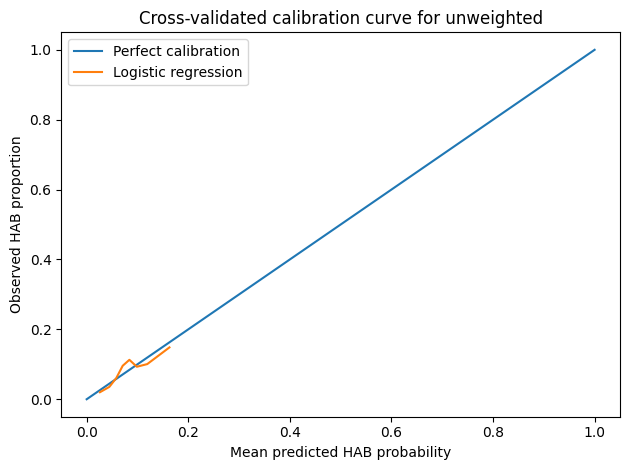

In [1191]:
obs_p_uw, p_p_uw = calibration_curve(y_true=y, y_prob=out_of_fold_prob_unweighted, n_bins=8, strategy='quantile')

plt.figure()

plt.plot([0, 1], [0, 1], label='Perfect calibration')

plt.plot(p_p_uw, obs_p_uw, label='Logistic regression')

plt.title('Cross-validated calibration curve for unweighted')
plt.xlabel('Mean predicted HAB probability')
plt.ylabel('Observed HAB proportion')

plt.legend()
plt.tight_layout()

plt.show()

## Calculate confidence intervals

In [1197]:
model_df = df[model_features + ['red_tide']].dropna()

X_final = model_df[model_features]
y_final = model_df['red_tide']

X_final = (X_final - X_final.mean()) / X_final.std()

# Add a constant
X_final = sm.add_constant(X_final)


logit = sm.Logit(y_final, X_final).fit()


conf_lower = logit.conf_int()[0]
conf_upper = logit.conf_int()[1]


final_results = pd.DataFrame({
    'Coefficient': logit.params,
    'Odds Ratio': np.exp(logit.params),
    '95% CI Lower': np.exp(conf_lower),
    '95% CI Upper': np.exp(conf_upper[1]),
    'p-value': logit.pvalues,
})


final_results['Reject'] = np.where(final_results['p-value'] < 0.05, 'True', 'False')


# Drop the constant
final_results = final_results.drop('const')

print(final_results)

Optimization terminated successfully.
         Current function value: 0.274918
         Iterations 7
              Coefficient  Odds Ratio  95% CI Lower  95% CI Upper       p-value Reject
chlorophyll      0.223490    1.250433      1.117365      1.399349  9.900027e-05   True
phaeopigment    -0.014823    0.985286      0.893965      1.399349  7.651758e-01  False
nitrate          0.075692    1.078630      0.842342      1.399349  5.485159e-01  False
phosphate       -0.068496    0.933797      0.764087      1.399349  5.032976e-01  False
silicon         -0.055083    0.946406      0.804926      1.399349  5.049313e-01  False
temp             0.496432    1.642849      1.430393      1.399349  2.124489e-12   True
salinity         0.275711    1.317468      1.146518      1.399349  1.010061e-04   True
oxygen_sat      -0.027802    0.972581      0.863240      1.399349  6.477435e-01  False
avg_depth       -0.247200    0.780984      0.665531      1.399349  2.455947e-03   True


C:\Users\Ehuan\AppData\Local\Temp\ipykernel_27772\1095366070.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  '95% CI Upper': np.exp(conf_upper[1]),
